# GT_VOL与PRED_VOL 可视化对比

/home/ccq/miniconda3/envs/r2_gaussian/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


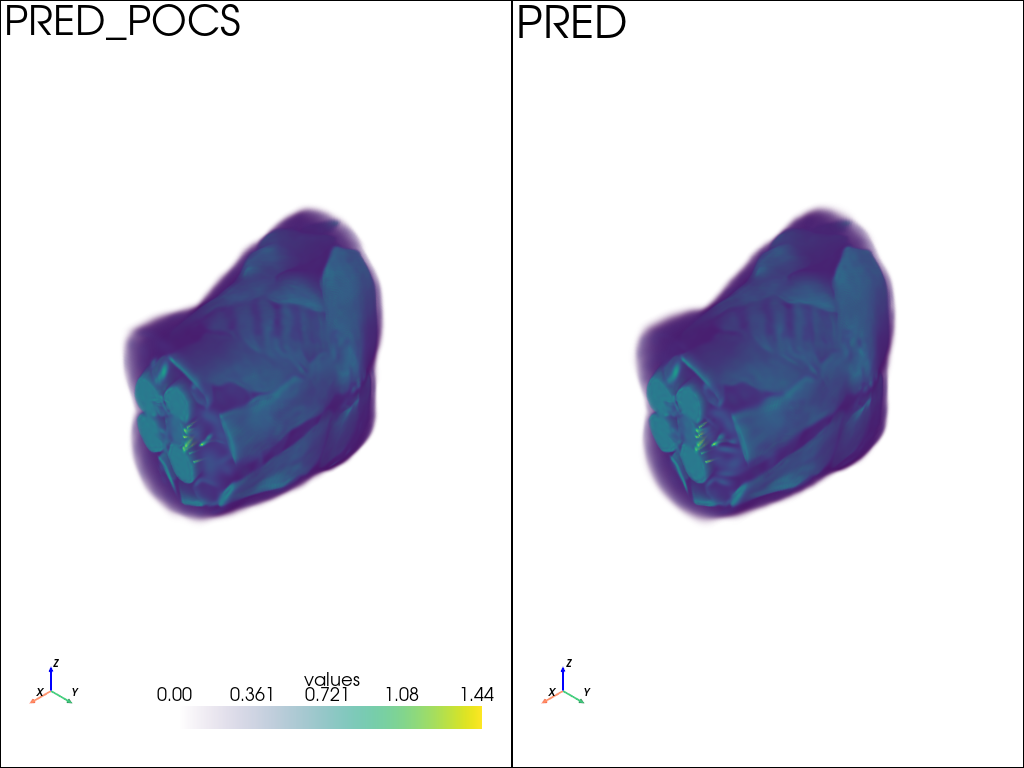

In [23]:
import pyvista as pv
import numpy as  np

gt_path = 'MRIdata/output_2026_3_14_2/point_cloud/iteration_1000/vol_gt.npy'
pred_path = 'MRIdata/output_2026_3_14_2/point_cloud/iteration_1000/vol_pred.npy'


gt_vol = np.load('MRIdata/outputs/exp_0316_2117_iter1000_L2loss_under/point_cloud/iteration_1000/vol_pred.npy')
pred_vol = np.load('MRIdata/outputs/exp_0316_2139_iter1000_L2loss_under/point_cloud/iteration_1000/vol_pred.npy')

plotter = pv.Plotter(shape=(1,2))
plotter.subplot(0,0)
plotter.add_volume(gt_vol[::-1,::-1,:])
plotter.add_text('PRED_POCS')
plotter.add_axes()

plotter.subplot(0,1)
plotter.add_volume(pred_vol[::-1,::-1,:])
plotter.add_text('PRED')
plotter.add_axes()

plotter.show()

# 重建指标(PSNR)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import torch,json
pred_path = "MRIdata/outputs/exp_0317_1538_iter1000_L2loss_under/point_cloud/iteration_1000/vol_pred.npy"
gt_path = "MRIdata/under/vol_gt.npy"

# pred_path = "MRIdata/outputs/exp_0316_1210_iter1000/point_cloud/iteration_1000/vol_pred.npy"
# gt_path = "MRIdata/outputs/exp_0316_1210_iter1000/point_cloud/iteration_1000/vol_gt.npy"

gt = np.load(gt_path)
pred = np.load(pred_path)
print(gt.shape)
print(pred.max())

def mse(img1, img2, mask=None):
    """MSE error

    Args:
        img1 (_type_): [b, c, h, w]
        img2 (_type_): [b, c, h, w]
        mask (_type_, optional): [b, c, h, w]. Defaults to None.

    Returns:
        _type_: _description_
    """
    n_channel = img1.shape[1]
    if mask is not None:
        img1 = img1.flatten(1)
        img2 = img2.flatten(1)

        mask = mask.flatten(1).repeat(1, n_channel)
        mask = torch.where(mask != 0, True, False)

        mse = torch.stack(
            [
                (((img1[i, mask[i]] - img2[i, mask[i]])) ** 2).mean(0, keepdim=True)
                for i in range(img1.shape[0])
            ],
            dim=0,
        )

    else:
        mse = (((img1 - img2)) ** 2).reshape(img1.shape[0], -1).mean(1, keepdim=True)
    return mse
def psnr(img1, img2, mask=None, pixel_max=1.0):
    """PSNR

    Args:
        img1 (_type_): [b, c, h, w]
        img2 (_type_): [b, c, h, w]
        mask (_type_, optional): [b, c, h, w]. Defaults to None.

    Returns:
        _type_: _description_
    """
    mse_out = mse(img1, img2, mask)
    psnr_out = 10 * torch.log10(pixel_max**2 / mse_out.float())
    if mask is not None:
        if torch.isinf(psnr_out).any():
            print(mse_out.mean(), psnr_out.mean())
            psnr_out = 10 * torch.log10(pixel_max**2 / mse_out.float())
            psnr_out = psnr_out[~torch.isinf(psnr_out)]

    return psnr_out

psnr_list = {}
for i in range(len(gt)):
    psnr_list[f"slice_{i+1}"] = psnr(torch.from_numpy(gt[i])[None,None],torch.from_numpy(pred[i])[None  ,None],pixel_max=1.0).squeeze(0).item()
print(psnr_list)
path = 'MRIdata/outputs/exp_0317_1538_iter1000_L2loss_under/eval/psnr2d.yml'
with open(path,'w',encoding='utf-8') as f:
    json.dump(psnr_list,f,indent=4)

(261, 350, 350)
1.435179
{'slice_1': 25.216861724853516, 'slice_2': 25.712034225463867, 'slice_3': 25.931127548217773, 'slice_4': 26.175151824951172, 'slice_5': 26.336105346679688, 'slice_6': 26.515827178955078, 'slice_7': 26.769025802612305, 'slice_8': 26.9091796875, 'slice_9': 26.932010650634766, 'slice_10': 26.893394470214844, 'slice_11': 26.858827590942383, 'slice_12': 26.994829177856445, 'slice_13': 26.870750427246094, 'slice_14': 26.885225296020508, 'slice_15': 26.842815399169922, 'slice_16': 26.72940444946289, 'slice_17': 26.810501098632812, 'slice_18': 26.92340087890625, 'slice_19': 26.979415893554688, 'slice_20': 26.930606842041016, 'slice_21': 26.90597915649414, 'slice_22': 26.80046272277832, 'slice_23': 26.782533645629883, 'slice_24': 26.693218231201172, 'slice_25': 26.46807861328125, 'slice_26': 26.58613395690918, 'slice_27': 26.603477478027344, 'slice_28': 26.52425765991211, 'slice_29': 26.48349952697754, 'slice_30': 26.543643951416016, 'slice_31': 26.51415252685547, 'slic

# 重建切片对比

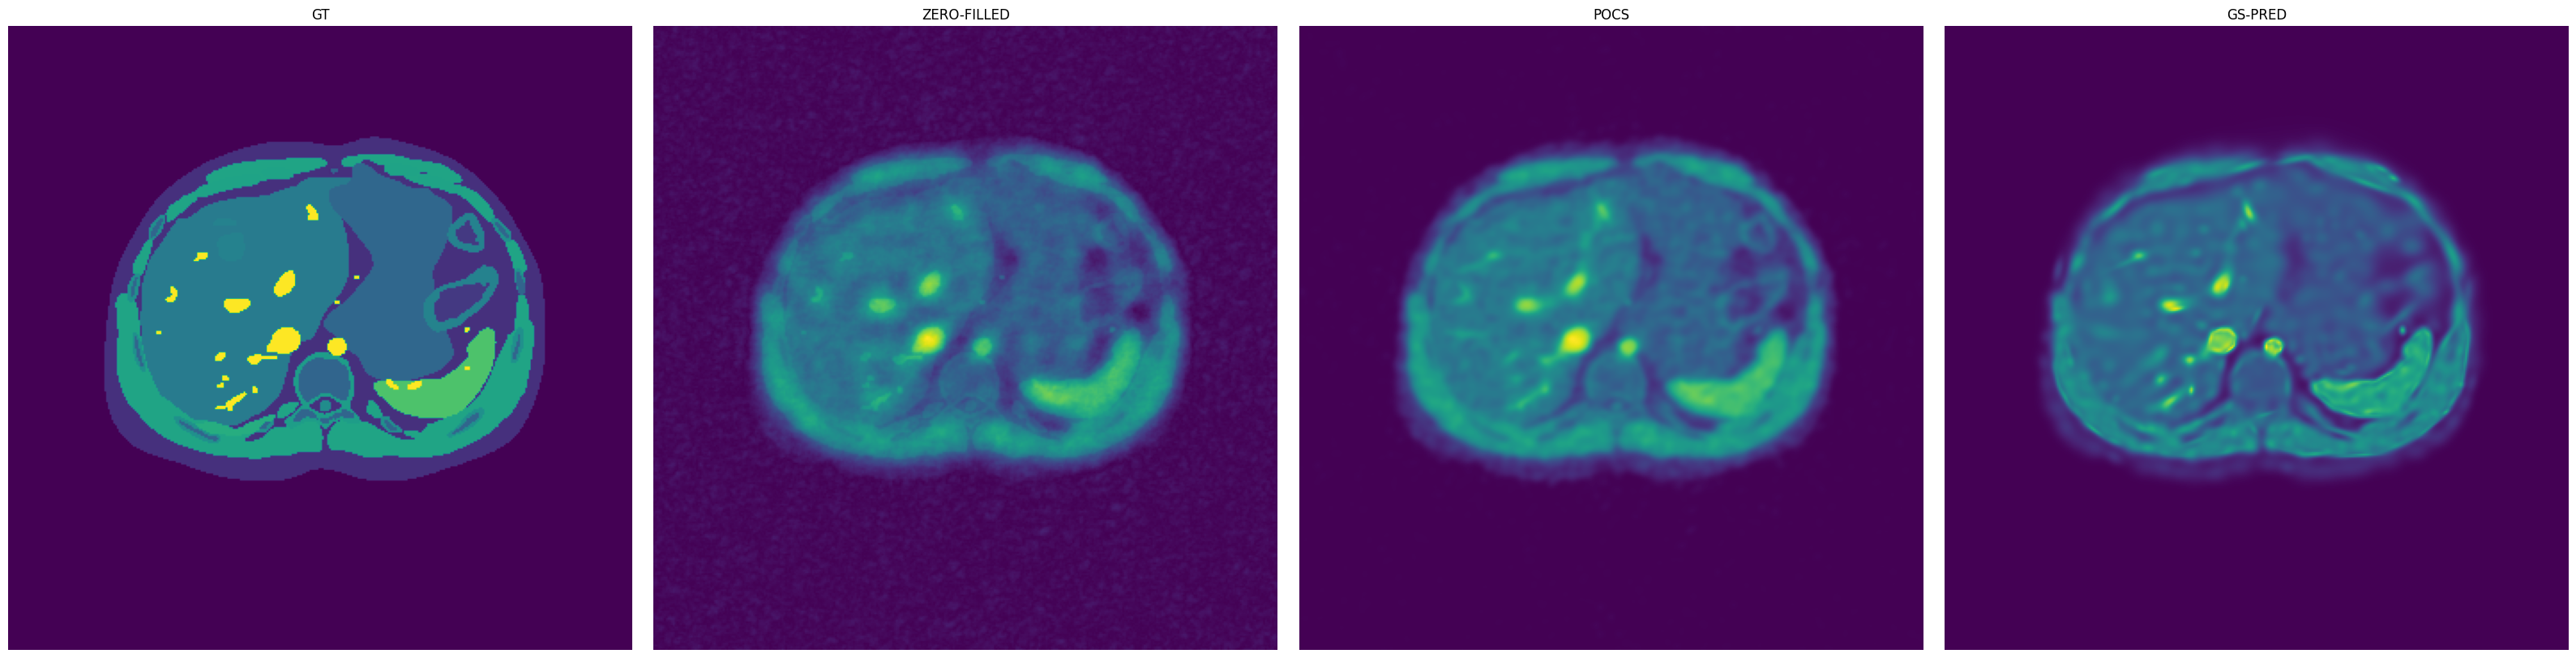

In [15]:
import matplotlib.pyplot as plt
import numpy as np
pred_path = "MRIdata/outputs/exp_0317_1558_iter1000_L2loss_under/point_cloud/iteration_1000/vol_pred.npy"
gt_path = "MRIdata/under/vol_gt.npy"
gt = np.load(gt_path)
gs_pred = np.load(pred_path)
pocs = np.load('MRIdata/under/pocs_recon.npy')
zero_filled = np.load('MRIdata/under/vol_gt_unsampled.npy')
plt.figure(figsize=(32,8))
plt.subplot(1,4,1)
plt.axis("off")
plt.title("GT")
plt.imshow(gt[130])

plt.subplot(1,4,2)
plt.axis("off")
plt.title("ZERO-FILLED")
plt.imshow(zero_filled[130])

plt.subplot(1,4,3)
plt.axis("off")
plt.title("POCS")
plt.imshow(pocs[130])

plt.subplot(1,4,4)
plt.axis("off")
plt.title("GS-PRED")
plt.imshow(gs_pred[130])
plt.tight_layout()
plt.show()

# from PIL import Image
# Image.fromarray(gt[130]).save()


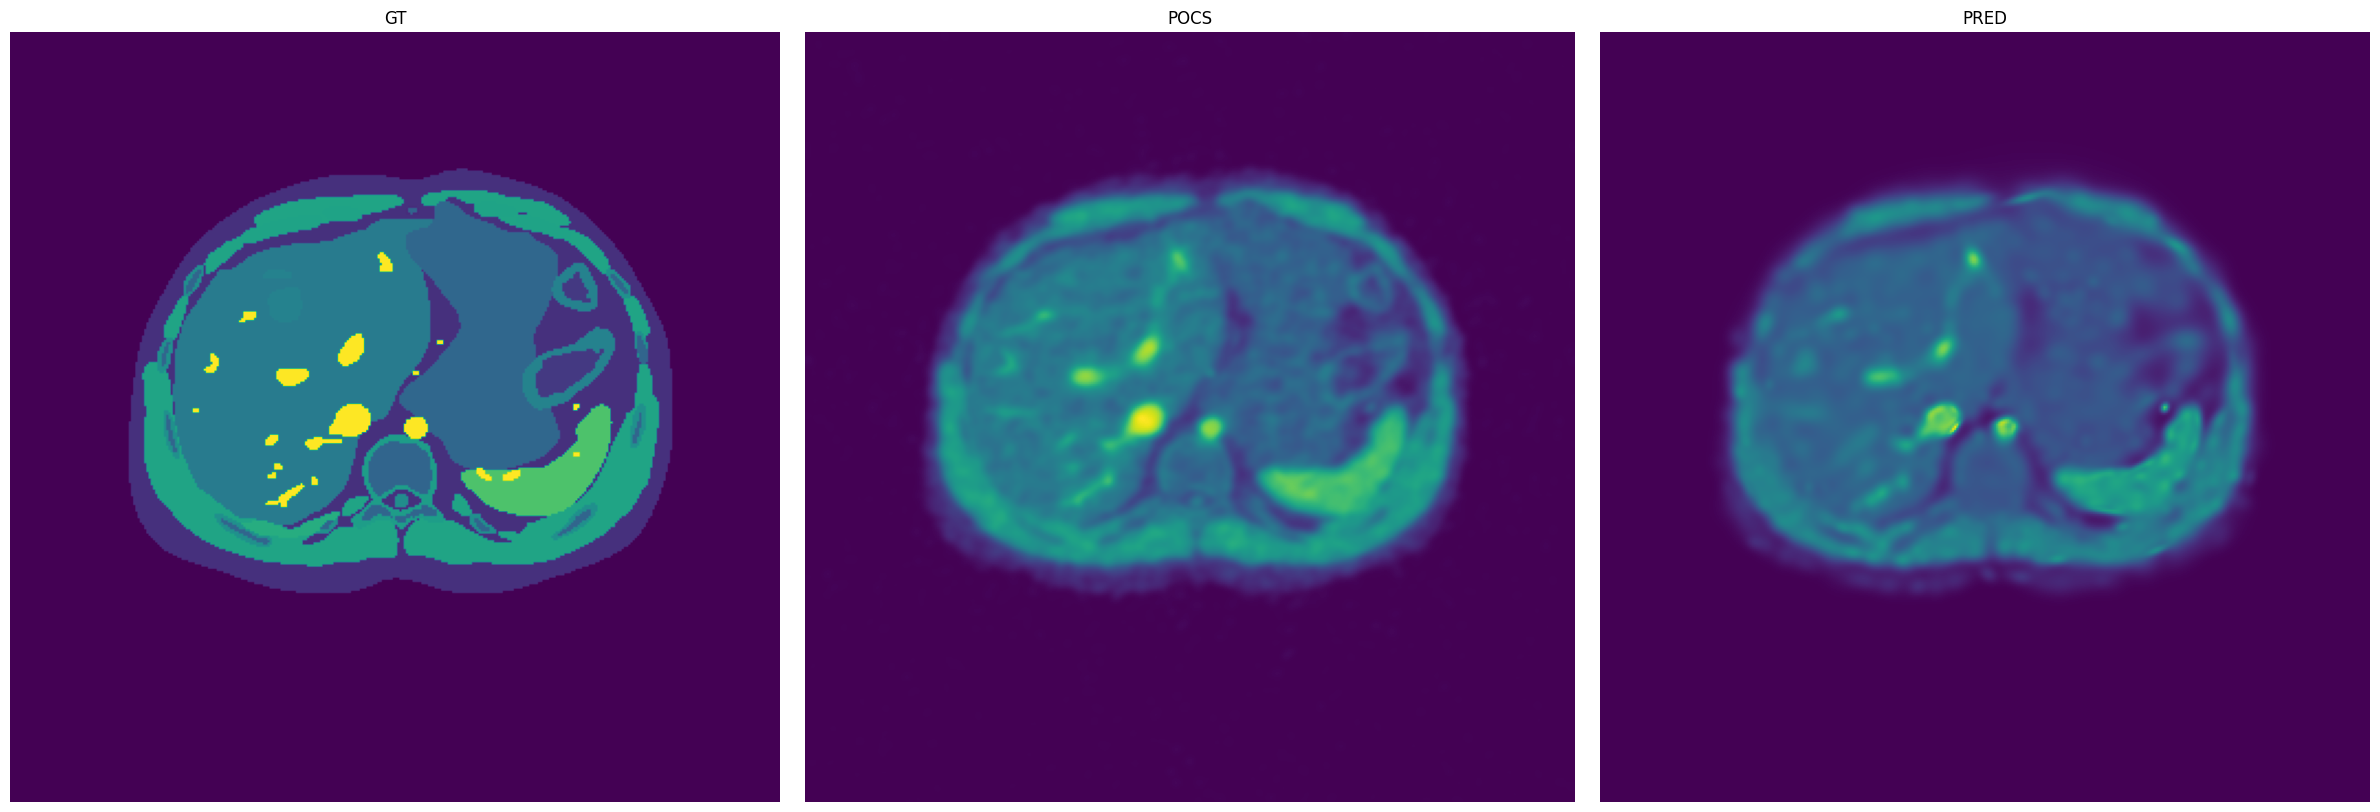

In [17]:
import matplotlib.pyplot as plt
import numpy as np
pred_path = "MRIdata/outputs/exp_0316_2032_iter1000_L2loss_under/point_cloud/iteration_1000/vol_pred.npy"
gt_path = "MRIdata/outputs/exp_0316_2032_iter1000_L2loss_under/point_cloud/iteration_1000/vol_gt.npy"
recon_pocs = np.load('MRIdata/under/pocs_recon.npy')
gt = np.load(gt_path)
pred = np.load(pred_path)

plt.figure(figsize=(24,8))
plt.subplot(1,3,1)
plt.axis("off")
plt.title("GT")
plt.imshow(gt[130])

plt.subplot(1,3,2)
plt.axis("off")
plt.title("POCS")
plt.imshow(recon_pocs[130])

plt.subplot(1,3,3)
plt.axis("off")
plt.title("PRED")
plt.imshow(pred[130])

plt.tight_layout()
plt.show()

# 3D mask 生成

In [2]:
import numpy as np

np.random.seed(0)

Nx, Ny, Nz = 261, 350, 350
total_lines = int(0.1*350*350)

y = np.arange(-Ny//2, Ny//2)
z = np.arange(-Nz//2, Nz//2)
ky, kz = np.meshgrid(y, z, indexing='ij')
r = np.sqrt(ky**2 + kz**2)

# define gaussian distribution
sigma = 100
probability_map = np.exp(-0.5 * (r**2) / (sigma**2))

# set up full sample area
acs_size = 32 # 设定中心 32x32 为全采样区
acs_mask = (np.abs(ky) < acs_size//2) & (np.abs(kz) < acs_size//2)

probability_map[acs_mask] = 0.0

lines_needed = total_lines - np.sum(acs_mask)

prob_flat = probability_map.flatten()
prob_flat = prob_flat / np.sum(prob_flat) 

# 不重复抽样
chosen_indices = np.random.choice(
    np.arange(Ny * Nz), 
    size=lines_needed, 
    replace=False, 
    p=prob_flat
)
# generate mask
mask_2d = acs_mask.flatten()
mask_2d[chosen_indices] = True
mask_2d = mask_2d.reshape((Ny, Nz)) # 还原回二维

mask_3d = np.zeros((Nx, Ny, Nz), dtype=bool)
mask_3d[:, mask_2d] = True



In [14]:
mask = np.array([[True,True],
                 [False,True]])
a = np.array([[1+1j,1+5j],
              [1+2j,1+3j]])
b = a*mask
print(b)
c = b.copy()
c[1,0]=0
print(c)
c==b

[[1.+1.j 1.+5.j]
 [0.+0.j 1.+3.j]]
[[1.+1.j 1.+5.j]
 [0.+0.j 1.+3.j]]


array([[ True,  True],
       [ True,  True]])

/home/ccq/miniconda3/envs/r2_gaussian/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


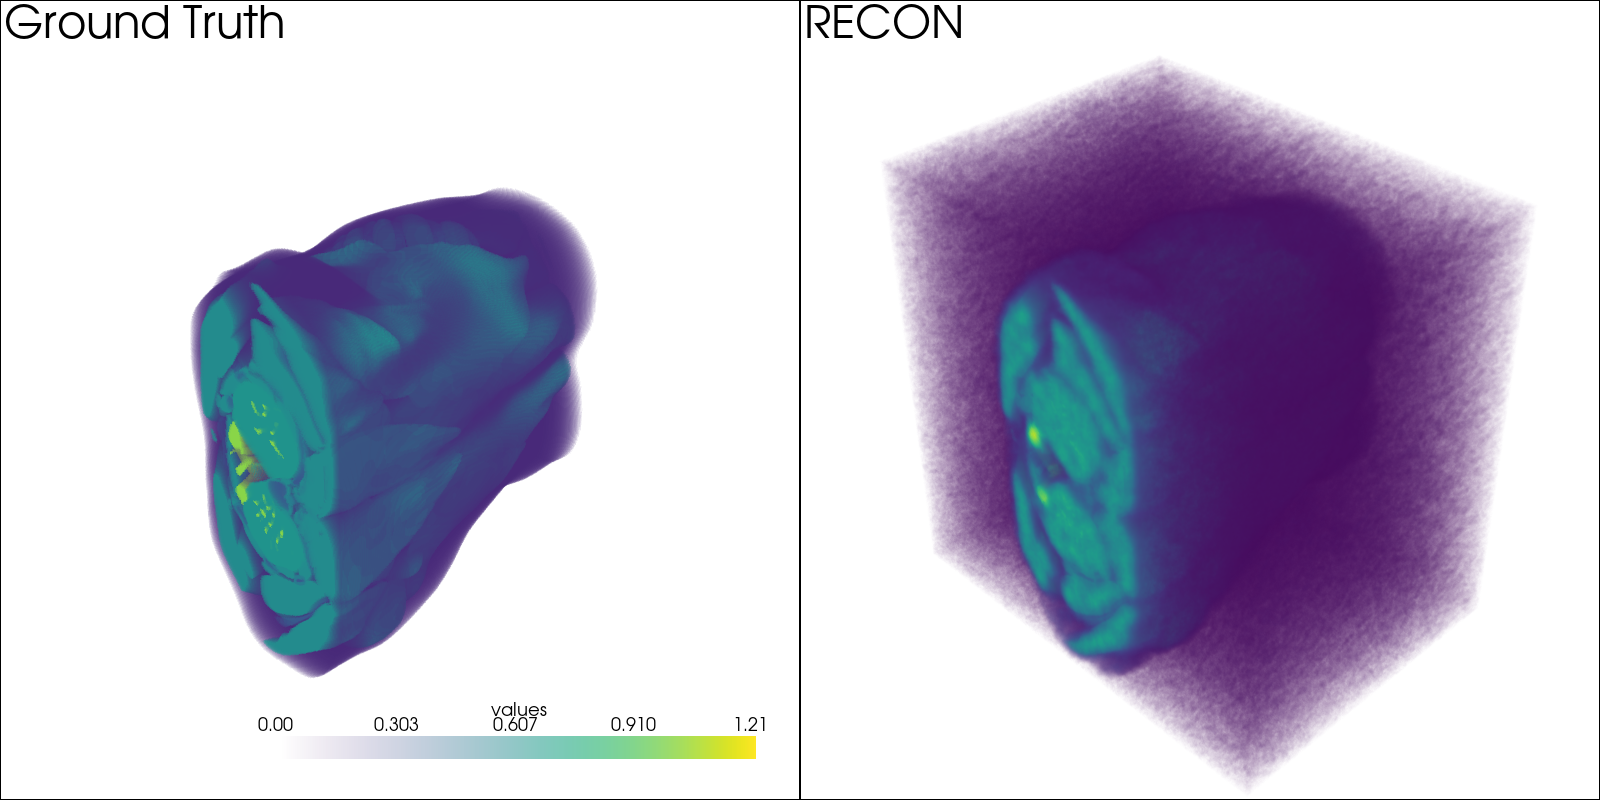

: 

In [ ]:

import numpy as np

# 假设 gt_volume 是你形状为 (261, 350, 350) 的真实图像数组
# gt_volume = ... 
# mask_3d 是你用前面代码生成的掩模，形状也是 (261, 350, 350)

# ==========================================
# 步骤 1: 图像域 -> K-space (全采样)
# ==========================================
# 注意：做 FFT 之前必须用 ifftshift 调整中心，做完后用 fftshift 移回来
# norm='ortho' 保证变换前后能量守恒，在 MRI 中非常关键
kspace_full = np.fft.fftshift(
    np.fft.fftn(np.fft.ifftshift(gt), norm='ortho')
)

# ==========================================
# 步骤 2: 模拟欠采样过程
# ==========================================
# 在 K-space 中与 mask 相乘 (未被采样的点变成 0+0j)
kspace_undersampled = kspace_full * mask_3d
# np.save('gt_k_space.npy',kspace_undersampled)
# ==========================================
# 步骤 3: 欠采样的 K-space -> 图像域 (零填充重建)
# ==========================================
img_undersampled_complex = np.fft.fftshift(
    np.fft.ifftn(np.fft.ifftshift(kspace_undersampled), norm='ortho')
)

# ==========================================
# 步骤 4: 获取最终用于查看或训练的幅度图 (Magnitude Image)
# ==========================================
# 因为傅里叶变换后结果是复数，我们需要取模长 (abs)
img_undersampled_mag = np.abs(img_undersampled_complex)

import pyvista as pv
plotter = pv.Plotter(shape=(1,2), window_size=(1600,800))

plotter.subplot(0, 0)
plotter.add_text("Ground Truth")
plotter.add_volume(gt, cmap="viridis")  # 可以指定colormap

# 右子图显示pred
plotter.subplot(0, 1)
plotter.add_text("RECON")
plotter.add_volume(img_undersampled_mag, cmap="viridis")

plotter.show()

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(1,3,1)
plt.title("x")
plt.imshow(mask_3d[0,...])

plt.subplot(1,3,2)
plt.title("y")
plt.imshow(mask_3d[:,175,:])

plt.subplot(1,3,3)
plt.title("z")
plt.imshow(mask_3d[...,175])

plt.show()

print(mask_3d[0,...].shape,mask_3d[:,175,:].shape,mask_3d[...,175].shape)


In [3]:
import pickle
path_k = 'MRIdata/outputs/exp_0316_1046_iter3000/point_cloud/iteration_1000/point_cloud.pickle'
path = 'MRIdata/outputs/exp_0315_2058_iter3000/point_cloud/iteration_1000/point_cloud.pickle'
with open(path,"rb") as f1, open(path_k,"rb") as f2:
    data = pickle.load(f1)
    data2 = pickle.load(f2)
print(data["density"].shape)
print(data2["density"].shape)




(56094, 1)
(56709, 1)
